In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

sys.path.insert(0, str(ROOT))

from src.data import BUSIDataset, discover_busi_samples
from src.reproducibility import seed_everything

seed_everything(42)

DATA_ROOT = ROOT / "data" / "raw" / "BUSI" / "BUSI"

samples = discover_busi_samples(DATA_ROOT)

plain_dataset = BUSIDataset(
    samples=samples,
    image_size=128,
    augment=False,
)

augmented_dataset = BUSIDataset(
    samples=samples,
    image_size=128,
    augment=True,
)

print("Samples:", len(samples))
print("Plain augmentation:", plain_dataset.augment)
print("Train augmentation:", augmented_dataset.augment)
print("Python executable:", sys.executable)

Samples: 629
Plain augmentation: False
Train augmentation: True
Python executable: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab\.venv\Scripts\python.exe


In [2]:
import pandas as pd


MANIFEST_PATH = (
    ROOT
    / "data"
    / "splits"
    / "busi_seed42.csv"
)

manifest = pd.read_csv(MANIFEST_PATH)

sample_by_filename = {
    sample.image_path.name: sample
    for sample in samples
}

train_filenames = manifest.loc[
    manifest["split"] == "train",
    "filename",
].tolist()

train_samples = [
    sample_by_filename[filename]
    for filename in train_filenames
]

plain_train_dataset = BUSIDataset(
    samples=train_samples,
    image_size=128,
    augment=False,
)

augmented_train_dataset = BUSIDataset(
    samples=train_samples,
    image_size=128,
    augment=True,
)

print("Manifest rows:", len(manifest))
print("Train samples:", len(train_samples))
print("Plain train augmentation:", plain_train_dataset.augment)
print(
    "Augmented train augmentation:",
    augmented_train_dataset.augment,
)

assert len(train_samples) == 438

print("Train dataset reconstruction: PASSED")

Manifest rows: 629
Train samples: 438
Plain train augmentation: False
Augmented train augmentation: True
Train dataset reconstruction: PASSED


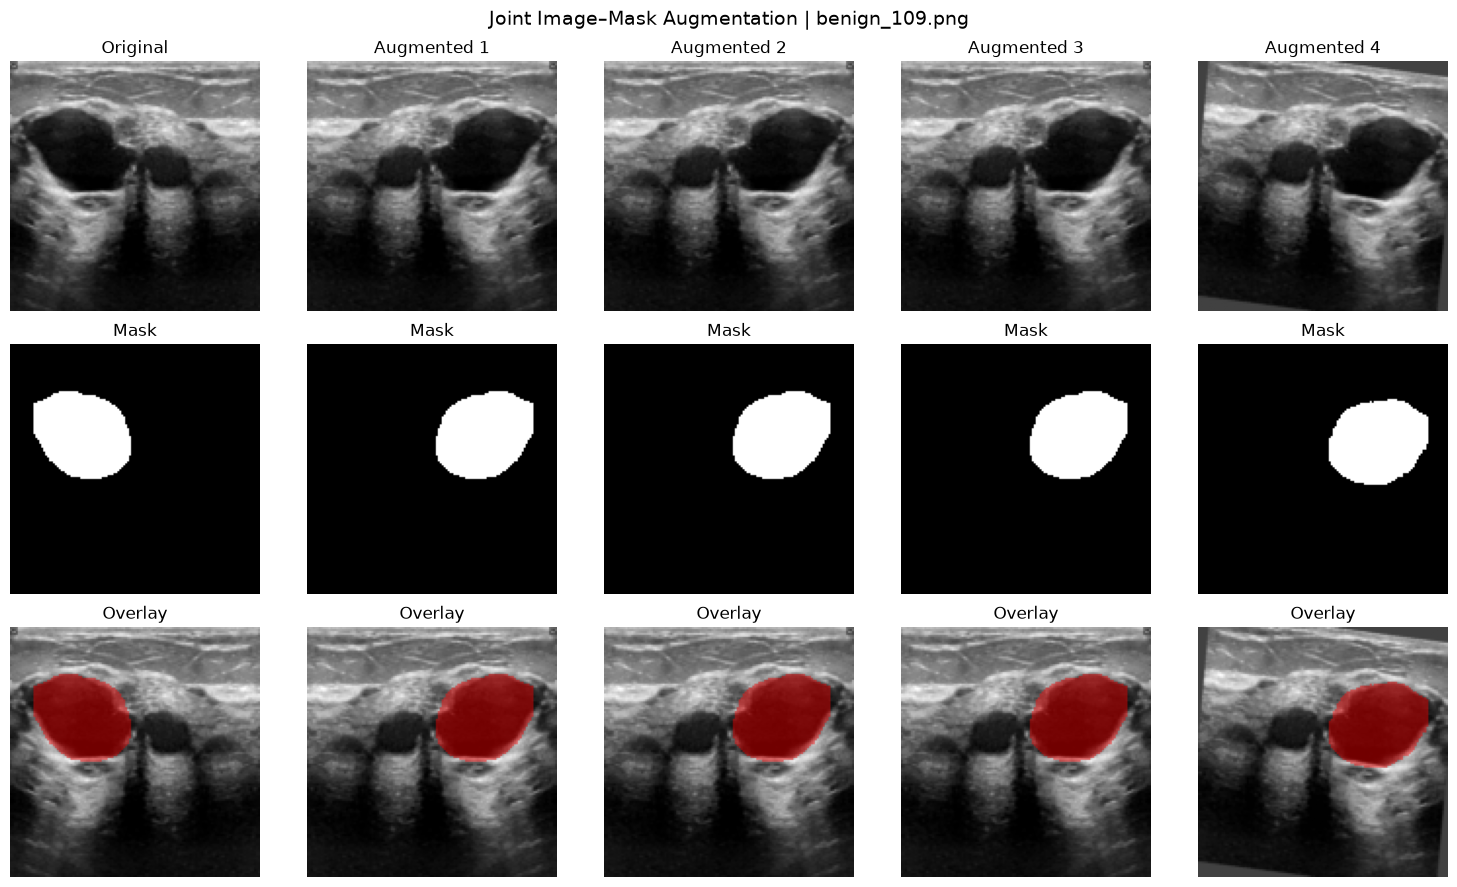

Selected filename: benign_109.png
Selected index: 7
Saved figure: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab\reports\figures\busi_augmentation_examples.png


In [3]:
# Find a sample with a medium-sized lesion for clear visualization.
sample_index = None

for index in range(len(plain_train_dataset)):
    item = plain_train_dataset[index]
    lesion_fraction = item["mask"].mean().item()

    if 0.05 <= lesion_fraction <= 0.20:
        sample_index = index
        break

assert sample_index is not None

seed_everything(123)

display_items = [
    ("Original", plain_train_dataset[sample_index]),
]

for variant_number in range(1, 5):
    display_items.append(
        (
            f"Augmented {variant_number}",
            augmented_train_dataset[sample_index],
        )
    )


fig, axes = plt.subplots(
    nrows=3,
    ncols=len(display_items),
    figsize=(15, 9),
)

for column, (title, item) in enumerate(display_items):
    image = item["image"].squeeze(0).numpy()
    mask = item["mask"].squeeze(0).numpy()

    axes[0, column].imshow(image, cmap="gray")
    axes[0, column].set_title(title)
    axes[0, column].axis("off")

    axes[1, column].imshow(mask, cmap="gray")
    axes[1, column].set_title("Mask")
    axes[1, column].axis("off")

    axes[2, column].imshow(image, cmap="gray")
    axes[2, column].imshow(
        np.ma.masked_where(mask == 0, mask),
        cmap="autumn",
        alpha=0.45,
    )
    axes[2, column].set_title("Overlay")
    axes[2, column].axis("off")


filename = display_items[0][1]["filename"]

fig.suptitle(
    f"Joint Image–Mask Augmentation | {filename}",
    fontsize=14,
)

plt.tight_layout()

figure_path = (
    ROOT
    / "reports"
    / "figures"
    / "busi_augmentation_examples.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Selected filename:", filename)
print("Selected index:", sample_index)
print("Saved figure:", figure_path)